## Problem Objective
*The objective of this task is to predict medical insurance charges for individuals based on personal data such as age, BMI, smoker status, and other important features.*

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("insurance.csv")

insurance = df.copy()

In [2]:
print(f"shape of insurance dataset: {insurance.shape}")
print(f"\ncolumns in insurance dataset: {insurance.columns}")
print(f"\nmissing values in insurance:\n {insurance.isnull().sum()}")
print(f"\nduplicate in insurance:\n {insurance.duplicated().sum()}")
print(f"\ndatatypes of insurance \n {insurance.dtypes}")
print(f"\ntop 5 data\n{insurance.head()}")

shape of insurance dataset: (1338, 7)

columns in insurance dataset: Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

missing values in insurance:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

duplicate in insurance:
 1

datatypes of insurance 
 age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

top 5 data
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [3]:
#Dropping duplicates fro dataset
insurance.drop_duplicates(inplace=True)
insurance.shape

(1337, 7)

In [4]:
print(f"statistical summary:\n {insurance.describe()}")

statistical summary:
                age          bmi     children       charges
count  1337.000000  1337.000000  1337.000000   1337.000000
mean     39.222139    30.663452     1.095737  13279.121487
std      14.044333     6.100468     1.205571  12110.359656
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.290000     0.000000   4746.344000
50%      39.000000    30.400000     1.000000   9386.161300
75%      51.000000    34.700000     2.000000  16657.717450
max      64.000000    53.130000     5.000000  63770.428010


In [5]:
#counting value of categorical columns
print(insurance["sex"].value_counts())
print(insurance["smoker"].value_counts())
print(insurance["region"].value_counts())
print(insurance["children"].value_counts())

sex
male      675
female    662
Name: count, dtype: int64
smoker
no     1063
yes     274
Name: count, dtype: int64
region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64
children
0    573
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64


*observation* : Statistical summary shows age ranges from 18–64, BMI from 15.9–53.1, and children from 0–5, all reasonable ranges. Charges show significant right skew, mean (13,279) is much higher than median (9,386), with max reaching 63,770 vs 75th percentile of 16,657 indicating high-value outliers likely driven by specific groups. Sex and region are balanced. Smoker column is imbalanced 1,063 non-smokers vs 274 smokers (roughly 80/20). These smokers may be driving the high charge outliers.

In [6]:
#Feature Engineering: Creating categorical bins from continuous BMI data
def bmi_category(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif bmi < 25:
        return 'Normal'
    elif bmi < 30:
        return 'Overweight'
    else:
        return 'Obese'

# Applying the classification function to the dataset
insurance['bmi_category'] = insurance['bmi'].apply(bmi_category)

insurance['bmi_category'].value_counts()

bmi_category
Obese          706
Overweight     386
Normal         225
Underweight     20
Name: count, dtype: int64

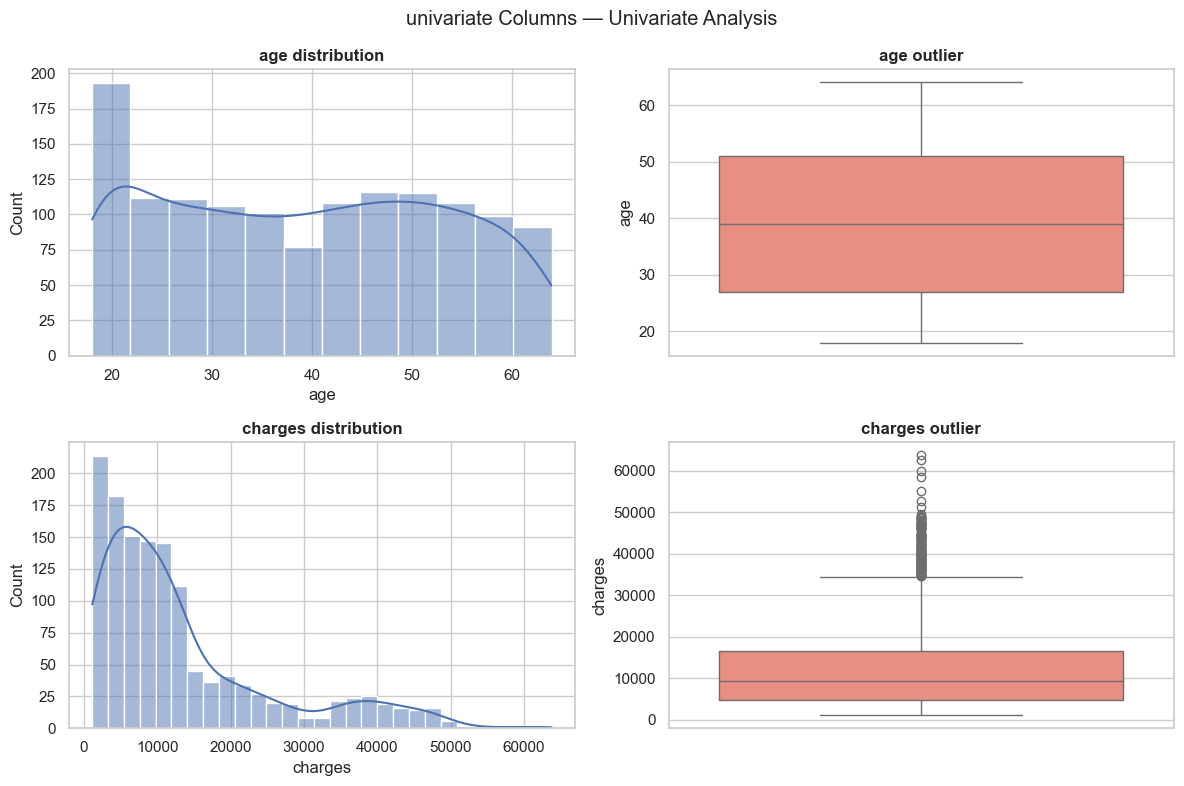

In [20]:
#univariate analysis of numerical columns 

sns.set_theme(style="whitegrid")

uni_num = ["age", "charges"]

fig, axes = plt.subplots(2, 2, figsize=(12,8))


for i, col in enumerate(uni_num):
    sns.histplot(data=insurance, x=col, kde=True, ax = axes[i][0])
    axes[i][0].set_title(f"{col} distribution", weight='bold')

    sns.boxplot(data=insurance[col], color="salmon", ax = axes[i][1])
    axes[i][1].set_title(f"{col} outlier", weight='bold')


plt.suptitle("univariate Columns — Univariate Analysis")
plt.tight_layout()
plt.show()

*observation*: Age distribution is fairly uniform (18–64) with a slight spike at age 20. No outliers in age, boxplot is clean. Charges are right-skewed, majority fall in 0–10k range with median around 9k. Outliers exist above 35k, these are likely smokers or high-BMI patients driving the charges up

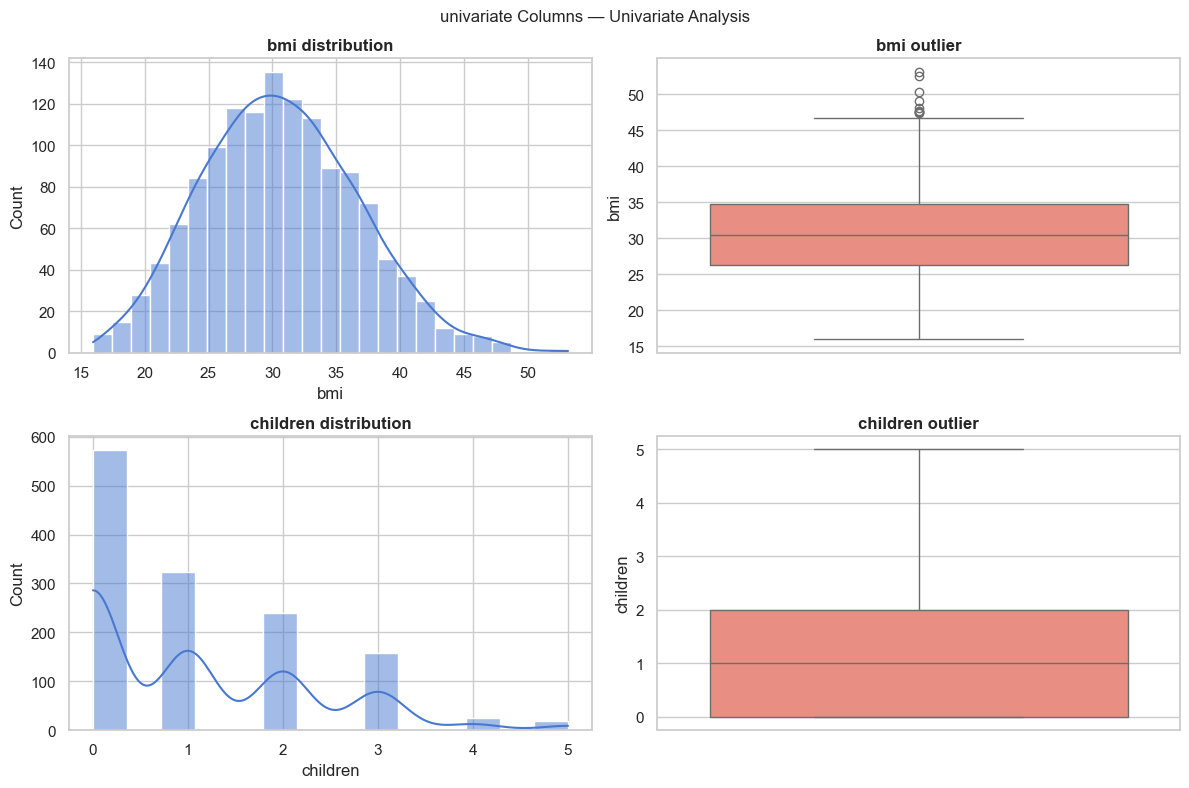

In [19]:
#univariate analysis of numerical columns 

uni_num2 = ["bmi", "children"]

fig, axes = plt.subplots(2, 2, figsize=(12,8))


for i, col in enumerate(uni_num2):
    sns.histplot(data=insurance, x=col, kde=True, ax = axes[i][0])
    axes[i][0].set_title(f"{col} distribution", weight='bold')

    sns.boxplot(data=insurance[col], color="salmon", ax = axes[i][1],)
    axes[i][1].set_title(f"{col} outlier", weight='bold')


plt.suptitle("univariate Columns — Univariate Analysis")
plt.tight_layout()
plt.show()

*Observation*:BMI is symmetric, centered around 30, with outliers above 46 suggesting extremely obese individuals. Children column is right-skewed, majority have 0 children (573), making the distribution heavily left-concentrated. Boxplot's missing lower whisker confirms this. Very few have 4-5 children."

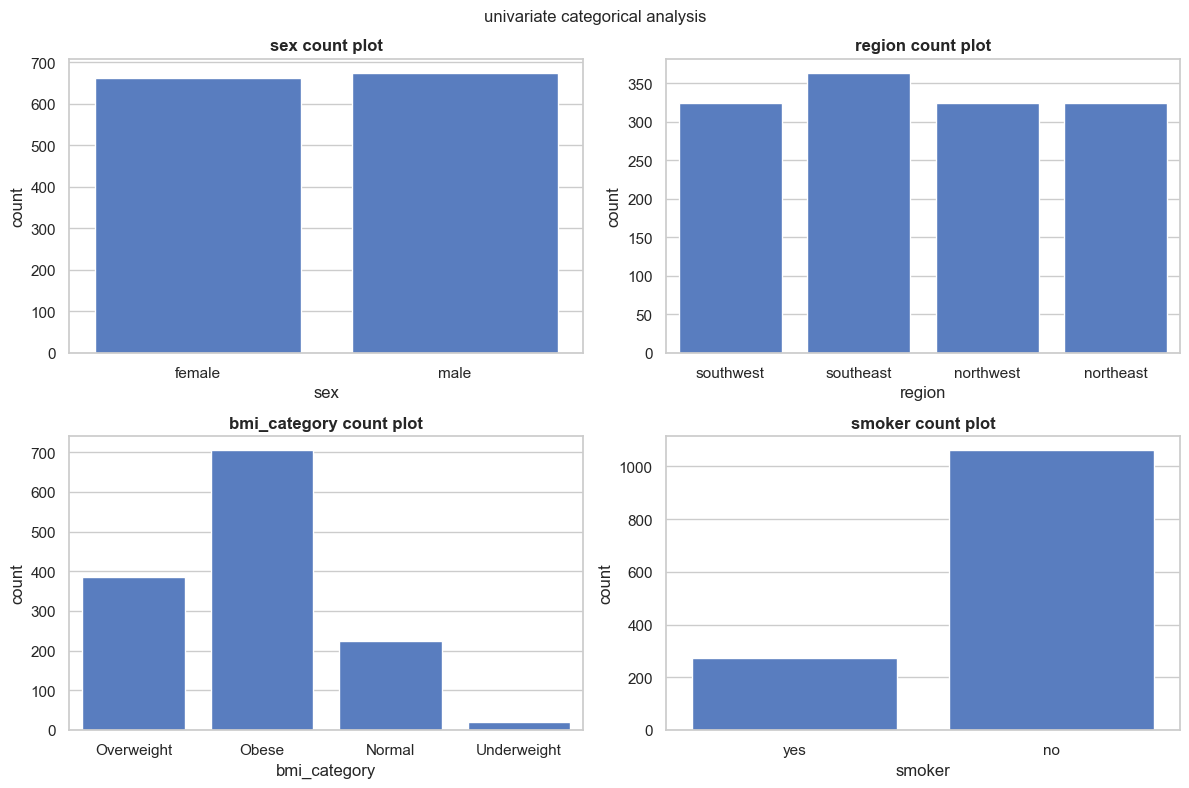

In [10]:
#univariate analysis of categorical columns

cat_uni = ["sex", "region", "bmi_category", "smoker"]

fig, axes = plt.subplots(2, 2, figsize = (12, 8))
axes = axes.flatten()

for i, col in enumerate(cat_uni):
    sns.countplot(data=insurance, x=col, ax = axes[i])
    axes[i].set_title(f"{col} count plot", weight='bold')

plt.suptitle("univariate categorical analysis")
plt.tight_layout()
plt.show()

*observation*: Gender is balanced, almost 50/50. Region is nearly balanced with Southeast slightly higher (~350 vs ~325 for others). BMI category shows majority are Obese (706) followed by Overweight (386), Normal (225), and very few Underweight (20) — confirming dataset is heavily skewed toward higher BMI. Smoker column is imbalanced, ~1,063 non-smokers vs ~274 smokers (80/20 split).

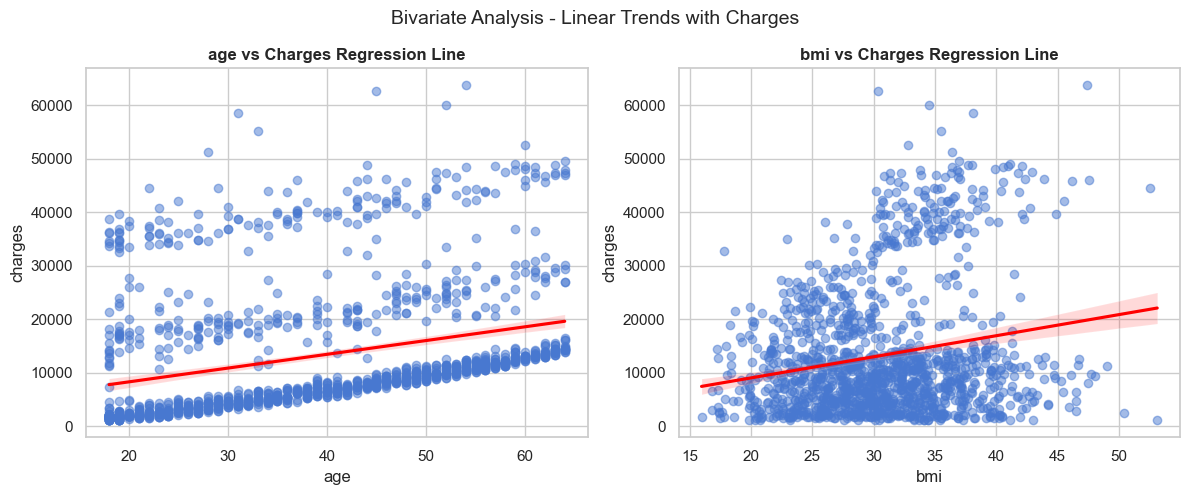

In [11]:
# Bivariate analysis using regression plots

num_col_for_bi= ["age", "bmi"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes = axes.flatten()

for i, col in enumerate(num_col_for_bi):
    # regplot maps x and y directly; it does not use 'hue'
    sns.regplot(data=insurance, x=col, y="charges", ax=axes[i], 
                scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
    axes[i].set_title(f"{col} vs Charges Regression Line", weight='bold')

plt.suptitle("Bivariate Analysis - Linear Trends with Charges", fontsize=14)
plt.tight_layout()
plt.show()

*observation*: Age shows a positive linear relationship with charges — older customers pay more. BMI also shows positive trend but with much more scatter, especially above BMI 40 where variation is very high. Both relationships exist but are weak individually — other factors like smoking likely influence charges more.

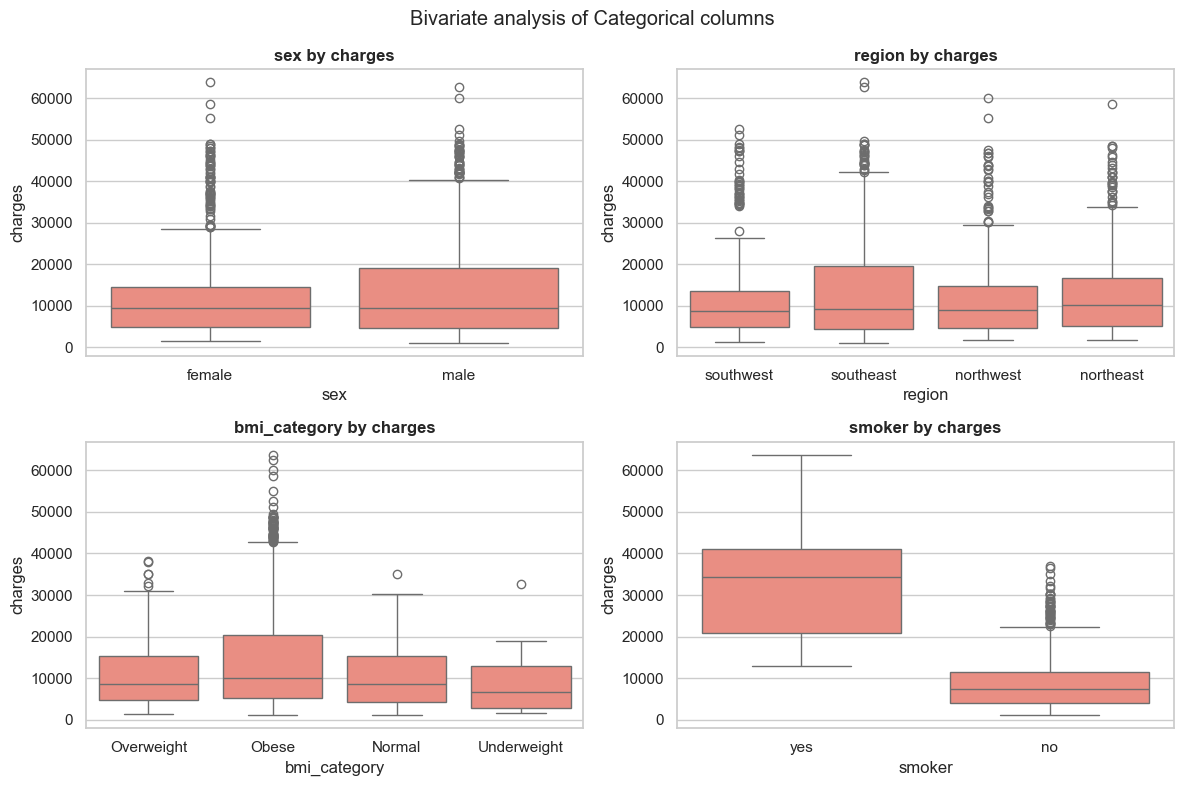

In [21]:
# Bivariate analysis of Categorical columns against Charges

cat_cols_for_bivariate = ["sex", "region", "bmi_category", "smoker"]

fig, axes = plt.subplots(2, 2, figsize=(12,8))
axes =axes.flatten()

for i, col in enumerate(cat_cols_for_bivariate):
    sns.boxplot(data=insurance, x=col, y="charges", color="salmon", ax=axes[i])
    axes[i].set_title(f"{col} by charges", weight='bold')

plt.suptitle("Bivariate analysis of Categorical columns")
plt.tight_layout()
plt.show()

*observation*: Sex: Both genders have similar median (~10k) but males have higher outliers (40k+), gender alone is a weak predictor.
Region: Southeast has highest outliers (42k+), possibly higher obesity rates. All regions have similar median ~10k.
BMI Category: Obese group has most outliers and highest spread — confirming BMI impacts extreme charges. Other categories are relatively stable.
Smoker: Strongest signal! Non-smokers median ~6k, smokers median ~36k — almost 6x difference! Smokers drive the extreme charges in this dataset.

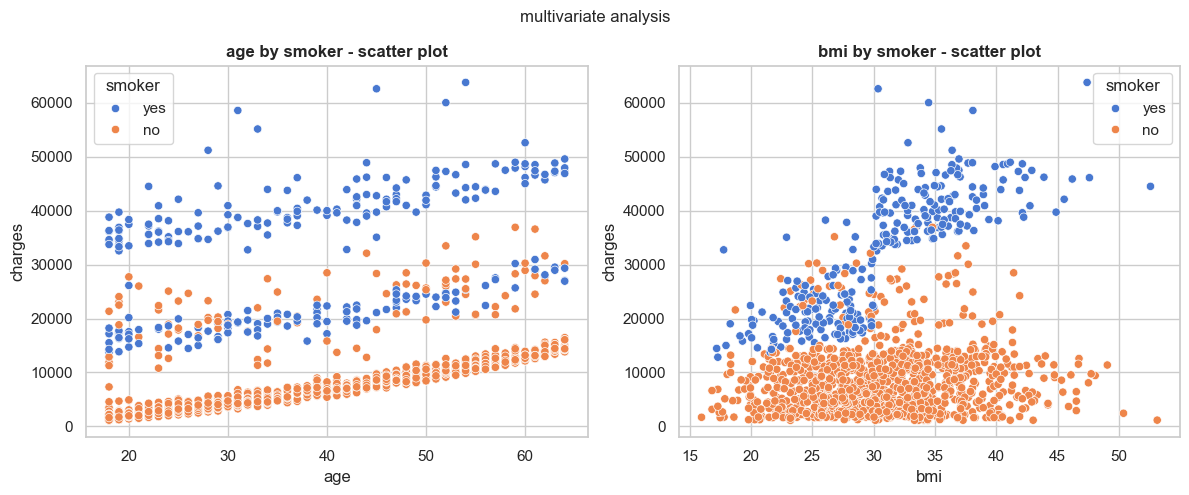

In [13]:
#multivarivate analysis of numerical col
mul_col = ["age", "bmi"]
fig, axes = plt.subplots(1, 2, figsize=(12,5))

for i, col in enumerate(mul_col):
    sns.scatterplot(data=insurance, x=col, y="charges", hue="smoker", ax = axes[i])
    axes[i].set_title(f"{col} by smoker - scatter plot", weight='bold')

plt.suptitle("multivariate analysis")
plt.tight_layout()
plt.show()

*observation*: Smokers consistently have higher charges across all ages and BMI levels. For non-smokers, charges increase linearly with age, a clear, predictable trend. For smokers, the pattern is different, charges are high regardless of age, but particularly extreme for high-BMI smokers (30+). Low-BMI smokers have relatively lower charges compared to high-BMI smokers. This suggests an interaction effect , smoking combined with high BMI dramatically increases charges, more than either factor alone."

in simple: Smoker + High BMI = high charges. Smoker + Low BMI = low charge. Non-smoker = cahrges gradully increase with age

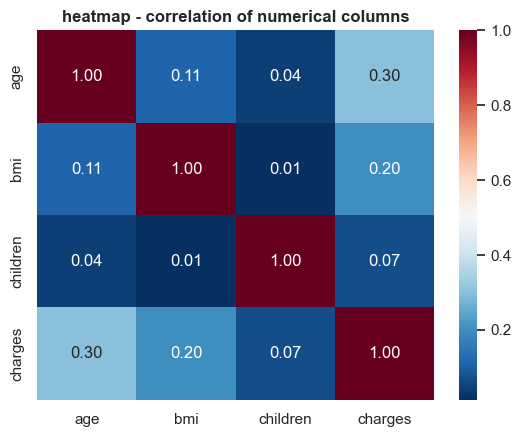

In [23]:
# Pure dataset ka aik sath multivariate analysis
sns.heatmap(insurance.corr(numeric_only=True), annot=True, fmt='.2f', cmap="RdBu_r")
plt.title("heatmap - correlation of numerical columns", weight='bold')
plt.show()

*observation*: we can clearly se age has high correlation with  charges(0.20) useful for model, bmi has little relationship with charges (0.20), children charges(0.7), bmi and age has 0.11, 

In [15]:
#encoding categorical columns for finding best correlation
ins_encoded = insurance.copy()
ins_encoded['smoker_num'] = ins_encoded['smoker'].map({'yes': 1, 'no': 0})
ins_encoded['sex_num'] = ins_encoded['sex'].map({'male': 1, 'female': 0})

print(ins_encoded[['age', 'bmi', 'children', 'smoker_num', 'sex_num', 'charges']].corr()['charges'])

age           0.298308
bmi           0.198401
children      0.067389
smoker_num    0.787234
sex_num       0.058044
charges       1.000000
Name: charges, dtype: float64


*observation*: Adding smoker as numeric confirms it's by far the strongest predictor of charges (0.79), much higher than age (0.30) or BMI (0.20). This validates what we saw in the scatter plots,  smoking status drives charges more than any other factor. Sex shows almost no correlation (0.06) and is likely not useful for the model.

In [16]:
#Scaling and feature engineering :

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

model_charges = insurance[["age", "smoker", "bmi", "region", "children", "charges"]]

model_charges = pd.get_dummies(data=model_charges, columns=["region"], drop_first=True, dtype=int)

le = LabelEncoder()
model_charges["smoker"] = le.fit_transform(model_charges["smoker"])

scaler = StandardScaler()
model_charges["bmi"] = scaler.fit_transform(model_charges[["bmi"]])
model_charges["age"] = scaler.fit_transform(model_charges[["age"]])


model_charges['smoker_bmi'] = model_charges['smoker'] * insurance['bmi'] #encode columns * not scale column bmi
model_charges.head()


,age,smoker,bmi,children,charges,region_northwest,region_southeast,region_southwest,smoker_bmi
0,-1.440418,1,-0.453160,0,16884.92400,0,0,1,27.9
1,-1.511647,0,0.509422,1,1725.55230,0,1,0,0.0
2,-0.799350,0,0.383155,3,4449.46200,0,1,0,0.0
3,-0.443201,0,-1.305052,0,21984.47061,1,0,0,0.0
4,-0.514431,0,-0.292456,0,3866.85520,1,0,0,0.0


*Observation:* We applied one-hot encoding on the region column and label encoding on smoker since it had only two values. Age and BMI were scaled using StandardScaler. For feature engineering, we created a smoker_bmi interaction feature using the original unscaled BMI column and the encoded smoker column, since multiplying scaled and unscaled values would have produced misleading results.

<h2 style="text-align: center;">Machine learning</h2>

In [17]:
# Initializing, training, and evaluating a Linear Regression model for insurance charges prediction

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

# Separating features from the continuous target variable
X = model_charges.drop(columns=["charges"])
y= model_charges["charges"]

# Splitting dataset 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Training the baseline Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Generating predictions on the validation test set
pred_charges = model.predict(X_test)
mae = mean_absolute_error(y_test, pred_charges)
mse = mean_squared_error(y_test, pred_charges)
r2score = r2_score(y_test, pred_charges)
rmse = root_mean_squared_error(y_test, pred_charges)

# Calculating regression error and variance metrics
print(f"mean absolute error = {mae}")
print(f"mean squared error = {mse}")
print(f"r2 score = {r2score}")
print(f"rmse = {rmse}")

# Displaying evaluation performance results
mae_percentage = (mae / y_test.mean()) * 100
print(f"mae percentage : {mae_percentage}")

mean absolute error = 2794.206033035436
mean squared error = 20791359.188705087
r2 score = 0.8868534799262198
rmse = 4559.754290387266
mae percentage : 19.578226969317605


*Observation*:Linear Regression was first tried before feature engineering, but the results were not good. After adding the smoker_bmi interaction feature, the model performed significantly better. Our main metric, R², improved to 88%, which is a strong result. RMSE was 4,559 this represents the average error in dollars, with larger errors penalized more heavily, making it a reliable measure for this task since large prediction misses are costly for an insurance company.

## Conclusion:
Our main objective was to predict insurance charges. The statistical summary showed age ranging from 18–64, BMI from 16–53, and charges heavily right-skewed with a max above 63K indicating outliers. The smoker column was imbalanced, and these smokers appeared to be driving most of the high-charge outliers.
Visualization confirmed this age distribution was fairly uniform, charges mostly fell in the 0–10K range with outliers above 35K, and BMI was symmetric and mostly in the obese range. Gender and region were both balanced.
The regplot showed a positive linear relationship between age and charges older people generally pay more. BMI also showed a positive relationship with charges, but with much more scatter, especially above BMI 40. Both relationships existed but were weak compared to smoking status.
The boxplot showed the obese BMI group had the most outliers. The scatter plot revealed that smokers had consistently higher charges, increasing linearly like non-smokers but at a much higher level especially for smokers with BMI above 30–40.
The heatmap showed age had the highest correlation with charges (0.30), followed by BMI (0.20), with age and BMI showing weak correlation with each other (0.11). After encoding smoker numerically, it showed the strongest correlation with charges (0.79) much higher than age or BMI.
We first trained the model without the smoker_bmi interaction feature, and it did not perform well. After adding this feature, model performance improved significantly. Our final R² score was 0.89 and RMSE was 4,559.75, with an MAE percentage of 19.6% both strong results that align well with our objective of accurately predicting insurance charges."